[LOAD 9100] MDEG= 8  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=12  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=16  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=20  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits  shape=(3459, 438, 437)
[LOAD 7000] MDEG= 8  file=IC3392_v3tk_mask_uptoCONT_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=12  file=IC3392_v3tk_mask_uptoCONT_MDEG12_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=16  file=IC3392_v3tk_mask_uptoCONT_MDEG16_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=20  file=IC3392_v3tk_mask_uptoCONT_MDEG20_line_cube.fits  shape=(1770, 438, 437)
[LOAD ORIG] IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits  shape=(3761, 438, 437)
[CONT] p90(|cont|)=68.17, floor=0.06817
[NOISE] median sigma(5218-5485)=4.953
[SAMPLE] Using 96620 spaxels out of 96620

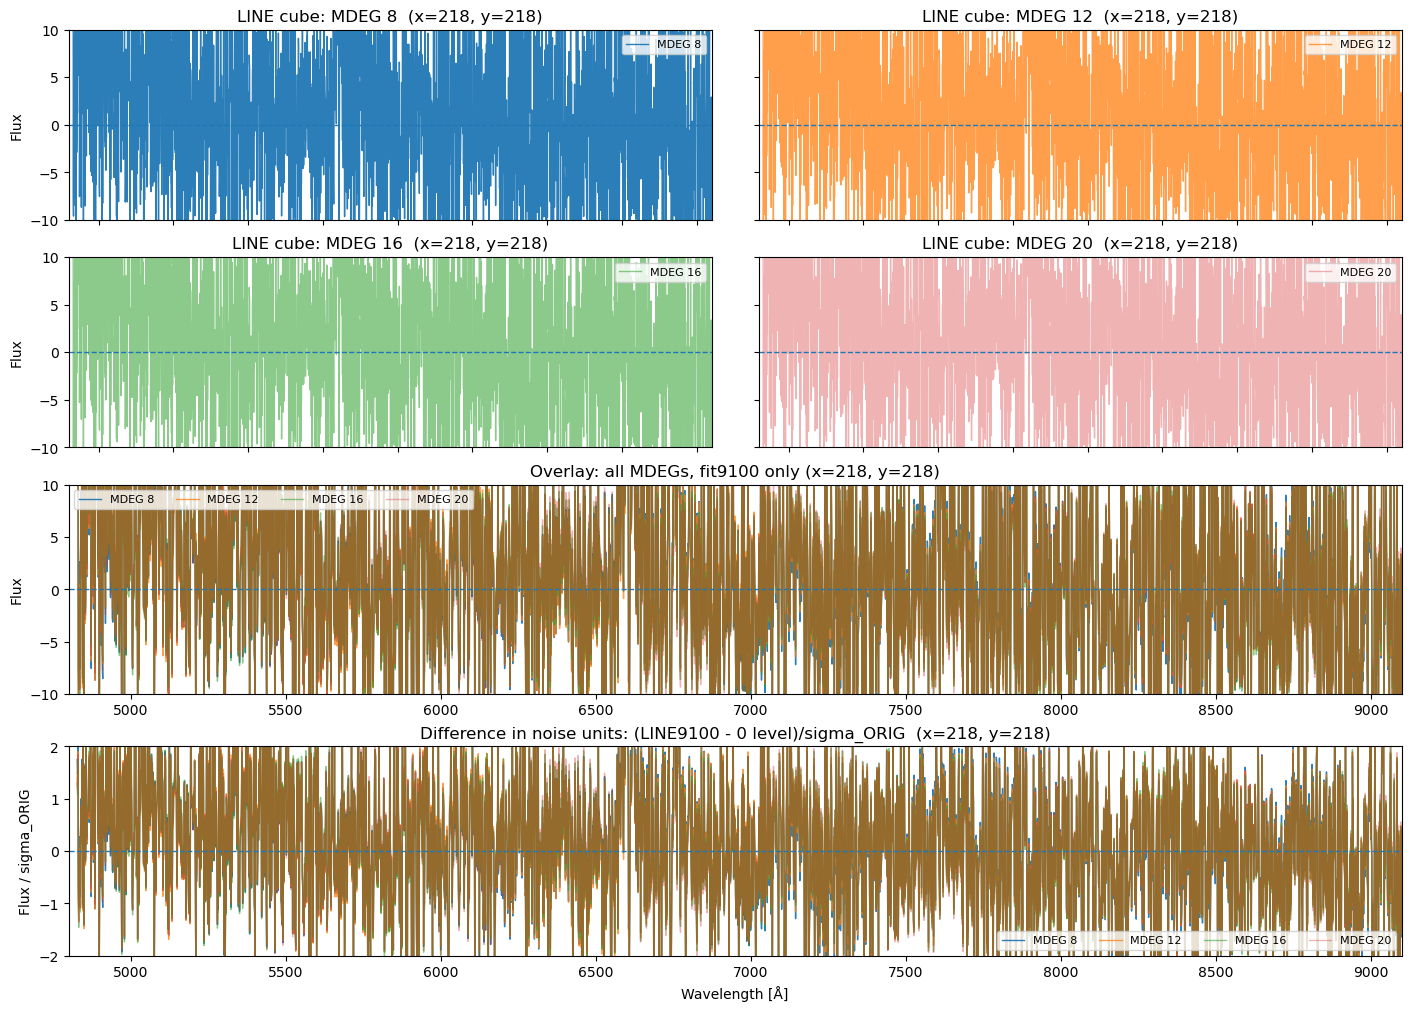

In [1]:
from pathlib import Path
import os
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)

# -----------------------------
# USER SETTINGS
# -----------------------------
base = Path.cwd()

run_ids_9100 = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}

run_ids_7000 = {
    8:  "IC3392_v3tk_mask_uptoCONT",
    12: "IC3392_v3tk_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_mask_uptoCONT_MDEG20",
}

if sorted(run_ids_9100) != sorted(run_ids_7000):
    raise ValueError("MDEG keys mismatch between 9100 and 7000 datasets")

MDEGS = sorted(run_ids_9100)
run_ids = run_ids_9100  # keep legacy name for later cells

linecube_name = lambda rid: base / rid / f"{rid}_line_cube.fits"

ORIG_CUBE_PATH = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")

windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "Hb_edge_4800_4920": (4800.0, 4920.0),
    "OIII_edge_4940_5060": (4940.0, 5060.0),
    "HaNII_edge_6500_6625": (6500.0, 6625.0),
    "SII_edge_6680_6760": (6680.0, 6760.0),
}

NSAMPLE  = 100000
STRIDE   = 4
NCPU     = min(os.cpu_count() or 8, 16)
DENOM_FLOOR_FRAC = 1e-3
CONT_FLOOR_FRAC = 1e-3
CONT_WIN = (5218.0, 5485.0)


# -----------------------------
# FITS HELPERS
# -----------------------------
def wave_from_fits_header(hdr):
    crval = hdr["CRVAL3"]
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3"))
    crpix = hdr.get("CRPIX3", 1.0)
    n = hdr["NAXIS3"]
    pix = np.arange(n) + 1
    return crval + (pix - crpix) * cdelt

def open_memmap_cube(path):
    hdul = fits.open(path, memmap=True)
    cube = hdul[0].data
    wave = wave_from_fits_header(hdul[0].header)
    return hdul, cube, wave

def open_memmap_cube_anyhdu(path: Path):
    hdul = fits.open(path, memmap=True)
    hdu = None
    for hh in hdul:
        if getattr(hh, "data", None) is None:
            continue
        if hh.data is None:
            continue
        if hh.data.ndim == 3 and hh.name.upper() != "STAT":
            hdu = hh
            break
    if hdu is None:
        raise RuntimeError(f"No 3D flux cube found in {path}")

    if "STAT" not in hdul:
        raise RuntimeError(f"STAT extension not found in {path}")
    stat_hdu = hdul["STAT"]
    if getattr(stat_hdu, "data", None) is None or stat_hdu.data.ndim != 3:
        raise RuntimeError(f"STAT extension is not a 3D variance cube in {path}")

    cube = hdu.data
    var_cube = stat_hdu.data
    wave = wave_from_fits_header(hdu.header)
    return hdul, cube, var_cube, wave

def continuum_level_map(cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Continuum window has no samples on this wavelength grid.")
    return np.nanmedian(cube[idx, :, :], axis=0)

def noise_level_map(var_cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Noise window has no samples on this wavelength grid.")
    med_var = np.nanmedian(var_cube[idx, :, :], axis=0)
    return np.sqrt(np.clip(med_var, 0.0, None))

def interp_spec_to_wave(spec_in, wave_in, wave_out):
    ok = np.isfinite(spec_in) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out, np.nan, dtype=float)
    return np.interp(wave_out, wave_in[ok], spec_in[ok], left=np.nan, right=np.nan)


def load_dataset(run_map, label):
    hduls, cubes, waves = {}, {}, {}
    for mdeg, rid in run_map.items():
        f = linecube_name(rid)
        hdul, cube, wave = open_memmap_cube(f)
        hduls[mdeg] = hdul
        cubes[mdeg] = cube
        waves[mdeg] = wave
        print(f"[LOAD {label}] MDEG={mdeg:>2}  file={f.name}  shape={cube.shape}")

    ref_spatial = cubes[MDEGS[0]].shape[1:]
    for mdeg in MDEGS:
        if cubes[mdeg].shape[1:] != ref_spatial:
            raise ValueError(f"{label}: spatial shape mismatch at MDEG {mdeg}: {cubes[mdeg].shape[1:]} vs {ref_spatial}")
    return hduls, cubes, waves[MDEGS[0]], ref_spatial


# -----------------------------
# LOAD BOTH FITTING-RANGE DATASETS
# -----------------------------
hduls_9100, cubes_9100, wave_9100, spatial_9100 = load_dataset(run_ids_9100, "9100")
hduls_7000, cubes_7000, wave_7000, spatial_7000 = load_dataset(run_ids_7000, "7000")

if spatial_9100 != spatial_7000:
    raise ValueError("Cross-range spatial shape mismatch between 9100 and 7000 datasets")

if not np.allclose(wave_9100[: min(len(wave_9100), len(wave_7000))], wave_7000[: min(len(wave_9100), len(wave_7000))], atol=1e-6, rtol=0):
    print("[WARN] wavelength grids differ; interpolation will be used where direct subtraction is needed")

ref_wave = wave_7000

datasets = {
    "9100": {"hduls": hduls_9100, "cubes": cubes_9100, "wave": wave_9100},
    "7000": {"hduls": hduls_7000, "cubes": cubes_7000, "wave": wave_7000},
}

# legacy aliases retained for downstream cells
hduls = hduls_9100
cubes = cubes_9100

# Load ORIGINAL flux cube + STAT variance cube
hdul_orig, cube_orig, var_orig, wave_orig = open_memmap_cube_anyhdu(ORIG_CUBE_PATH)
print(f"[LOAD ORIG] {ORIG_CUBE_PATH.name}  shape={cube_orig.shape}")

if cube_orig.shape[1:] != spatial_9100:
    raise ValueError(f"ORIG cube spatial shape mismatch: {cube_orig.shape[1:]} vs {spatial_9100}")
if var_orig.shape != cube_orig.shape:
    raise ValueError(f"STAT variance shape mismatch: {var_orig.shape} vs {cube_orig.shape}")

cont_map = continuum_level_map(cube_orig, wave_orig, *CONT_WIN)
cont_finite = np.isfinite(cont_map)
cont_scale = np.nanpercentile(np.abs(cont_map[cont_finite]), 90)
CONT_FLOOR = cont_scale * CONT_FLOOR_FRAC
print(f"[CONT] p90(|cont|)={cont_scale:.4g}, floor={CONT_FLOOR:.4g}")

noise_map = noise_level_map(var_orig, wave_orig, *CONT_WIN)
noise_finite = np.isfinite(noise_map)
noise_scale = np.nanpercentile(noise_map[noise_finite], 50)
print(f"[NOISE] median sigma({CONT_WIN[0]:.0f}-{CONT_WIN[1]:.0f})={noise_scale:.4g}")


# -----------------------------
# BUILD RANDOM SPAXEL SAMPLE (valid in both ranges)
# -----------------------------
w1_ref, w2_ref = windows["cont_5218_5485"]
idx_ref_9100 = (wave_9100 >= w1_ref) & (wave_9100 <= w2_ref)
idx_ref_7000 = (wave_7000 >= w1_ref) & (wave_7000 <= w2_ref)

sub_9100_ref = cubes_9100[MDEGS[0]][idx_ref_9100, :, :]
sub_7000_ref = cubes_7000[MDEGS[0]][idx_ref_7000, :, :]
valid_ref = np.isfinite(sub_9100_ref).any(axis=0) & np.isfinite(sub_7000_ref).any(axis=0)

yy, xx = np.where(valid_ref)
n_valid = yy.size
if n_valid == 0:
    raise RuntimeError("No valid spaxels found in both ranges for the reference window")

rng = np.random.default_rng(42)
take = min(NSAMPLE, n_valid)
sel_idx = rng.choice(n_valid, size=take, replace=False)
ys = yy[sel_idx]
xs = xx[sel_idx]
print(f"[SAMPLE] Using {take} spaxels out of {n_valid} jointly-valid spaxels")
print(f"[PARALLEL] Using {NCPU} threads")

cont_samp = cont_map[ys, xs]
cont_samp_denom = np.sign(cont_samp) * np.maximum(np.abs(cont_samp), CONT_FLOOR)
noise_samp = noise_map[ys, xs]


# -----------------------------
# STATS HELPERS (PER RANGE, PER MDEG)
# -----------------------------
def compute_window_stats_for_dataset(dataset_key, mdeg, w1, w2):
    cube = datasets[dataset_key]["cubes"][mdeg]
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return dataset_key, mdeg, None, np.full(take, np.nan), np.full(take, np.nan)

    slab = cube[idx, :, :]
    sub = slab[:, ys, xs]

    valid = np.isfinite(sub).any(axis=0)
    med_all = np.full(take, np.nan, dtype=float)
    rms_all = np.full(take, np.nan, dtype=float)

    if valid.sum() == 0:
        return dataset_key, mdeg, {"n_valid": 0, "n_tot": int(valid.size)}, med_all, rms_all

    subv = sub[:, valid]
    med = np.nanmedian(subv, axis=0)
    mad = np.nanmedian(np.abs(subv - med[None, :]), axis=0)
    rms = 1.4826 * mad

    med_all[valid] = med
    rms_all[valid] = rms

    stats = {
        "n_valid": int(valid.sum()),
        "n_tot": int(valid.size),
        "med_p16": float(np.nanpercentile(med, 16)),
        "med_p50": float(np.nanpercentile(med, 50)),
        "med_p84": float(np.nanpercentile(med, 84)),
        "rms_p16": float(np.nanpercentile(rms, 16)),
        "rms_p50": float(np.nanpercentile(rms, 50)),
        "rms_p84": float(np.nanpercentile(rms, 84)),
    }
    return dataset_key, mdeg, stats, med_all, rms_all


def window_rms_map(dataset_key, mdeg, w1, w2, stride=4):
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return None
    slab = datasets[dataset_key]["cubes"][mdeg][idx, ::stride, ::stride]
    med = np.nanmedian(slab, axis=0)
    mad = np.nanmedian(np.abs(slab - med[None, :, :]), axis=0)
    return 1.4826 * mad


# # -----------------------------
# # MAIN WINDOW LOOP: (9100 - 7000) at fixed MDEG
# # -----------------------------
# for wname, (w1, w2) in windows.items():
#     print("\n" + "=" * 90)
#     print(f"WINDOW: {wname}  ({w1:.1f}–{w2:.1f} Å)")

#     stats_by = {"9100": {}, "7000": {}}
#     med_by = {"9100": {}, "7000": {}}
#     rms_by = {"9100": {}, "7000": {}}

#     with ThreadPoolExecutor(max_workers=NCPU) as ex:
#         futures = [
#             ex.submit(compute_window_stats_for_dataset, dk, mdeg, w1, w2)
#             for dk in ("9100", "7000")
#             for mdeg in MDEGS
#         ]
#         for fut in as_completed(futures):
#             dk, mdeg, stats, med_all, rms_all = fut.result()
#             stats_by[dk][mdeg] = stats
#             med_by[dk][mdeg] = med_all
#             rms_by[dk][mdeg] = rms_all

#     print("\n  Absolute summaries by fitting range:")
#     for mdeg in MDEGS:
#         for dk in ("9100", "7000"):
#             s = stats_by[dk][mdeg]
#             if s is None or s.get("n_valid", 0) == 0:
#                 print(f"    MDEG={mdeg:>2} [{dk}]: no valid sampled spaxels")
#                 continue
#             print(
#                 f"    MDEG={mdeg:>2} [{dk}]: "
#                 f"med=({s['med_p16']:.4g},{s['med_p50']:.4g},{s['med_p84']:.4g})  "
#                 f"rms=({s['rms_p16']:.4g},{s['rms_p50']:.4g},{s['rms_p84']:.4g})  "
#                 f"N={s['n_valid']}/{s['n_tot']}"
#             )

#     print("\n  Cross-fitting-range comparison (9100 - 7000) at fixed MDEG:")
#     drms_pct_by_mdeg = {}
#     dmed_by_mdeg = {}

#     for mdeg in MDEGS:
#         med9100 = med_by["9100"][mdeg]
#         med7000 = med_by["7000"][mdeg]
#         rms9100 = rms_by["9100"][mdeg]
#         rms7000 = rms_by["7000"][mdeg]

#         ok = np.isfinite(med9100) & np.isfinite(med7000) & np.isfinite(rms9100) & np.isfinite(rms7000)
#         if ok.sum() == 0:
#             print(f"    MDEG={mdeg:>2}: no overlap-valid spaxels")
#             drms_pct_by_mdeg[mdeg] = np.array([])
#             dmed_by_mdeg[mdeg] = np.array([])
#             continue

#         dmed = med9100[ok] - med7000[ok]
#         drms = rms9100[ok] - rms7000[ok]

#         denom_ok = np.isfinite(rms7000[ok]) & (rms7000[ok] > 0)
#         if denom_ok.any():
#             floor = np.nanpercentile(rms7000[ok][denom_ok], 5) * DENOM_FLOOR_FRAC
#             denom = np.maximum(rms7000[ok], floor)
#             drms_pct = drms / denom * 100.0
#         else:
#             drms_pct = np.full(ok.sum(), np.nan)

#         dmed_by_mdeg[mdeg] = dmed
#         drms_pct_by_mdeg[mdeg] = drms_pct[np.isfinite(drms_pct)]

#         p16m, p50m, p84m = np.nanpercentile(dmed, [16, 50, 84])
#         p16r, p50r, p84r = np.nanpercentile(drms, [16, 50, 84])
#         print(
#             f"    MDEG={mdeg:>2}: ΔMED=(p16,p50,p84)=({p16m:.3g},{p50m:.3g},{p84m:.3g})  "
#             f"ΔRMS(abs)=({p16r:.3g},{p50r:.3g},{p84r:.3g})"
#         )

#         if drms_pct_by_mdeg[mdeg].size > 0:
#             p16, p50, p84 = np.nanpercentile(drms_pct_by_mdeg[mdeg], [16, 50, 84])
#             print(f"              ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000: ({p16:.3g}, {p50:.3g}, {p84:.3g})")

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = drms_pct_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"ΔRMS[%] between fitting ranges (9100-7000): {wname}")
    # plt.xlabel("100*(RMS9100 - RMS7000) / RMS7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = dmed_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"Δ median residual (9100-7000): {wname}")
    # plt.xlabel("Median9100 - Median7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # for mdeg in MDEGS:
    #     rms_9100_map = window_rms_map("9100", mdeg, w1, w2, stride=STRIDE)
    #     rms_7000_map = window_rms_map("7000", mdeg, w1, w2, stride=STRIDE)

    #     if rms_9100_map is None or rms_7000_map is None:
    #         continue

    #     finite_7000 = np.isfinite(rms_7000_map) & (rms_7000_map > 0)
    #     if not finite_7000.any():
    #         continue

    #     floor = np.nanpercentile(rms_7000_map[finite_7000], 5) * DENOM_FLOOR_FRAC
    #     denom = np.maximum(rms_7000_map, floor)
    #     pct_map = (rms_9100_map - rms_7000_map) / denom * 100.0

    #     finite = np.isfinite(pct_map)
    #     v = np.nanpercentile(np.abs(pct_map[finite]), 99) if finite.any() else 10.0

    #     plt.figure(figsize=(6, 5))
    #     plt.imshow(pct_map, origin="lower", vmin=-v, vmax=v)
    #     plt.colorbar(label=f"ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000  (MDEG={mdeg}, stride={STRIDE})")
    #     plt.title(f"% RMS-change map (9100-7000): {wname}, MDEG={mdeg}")
    #     plt.xlabel("x [pix/stride]")
    #     plt.ylabel("y [pix/stride]")
    #     plt.show()


# -----------------------------
# SPAXEL SPECTRUM OVERLAY (x,y from Mapviewer)
# -----------------------------
# Updated plotting: show spectra up to 9100 and use LINE9100-only noise-normalized panel
XPIX = 218
YPIX = 218

def plot_spaxel_suite(
    x, y,
    mdegs=(8, 12, 16, 20),
    wmin=4800,
    wmax=9100,
):
    w9100 = wave_9100
    sel9100 = (w9100 >= wmin) & (w9100 <= wmax)

    mdegs = tuple(mdegs)
    mmin, mmax = min(mdegs), max(mdegs)

    def alpha_for_mdeg(m, a_hi=0.95, a_lo=0.35):
        # higher MDEG -> lower alpha
        if mmax == mmin:
            return 0.8
        t = (m - mmin) / (mmax - mmin)
        return a_hi - t * (a_hi - a_lo)

    # consistent color per MDEG across all panels
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle_colors:
        cycle_colors = [f"C{i}" for i in range(10)]
    mdeg_sorted = sorted(mdegs)
    color_map = {m: cycle_colors[i % len(cycle_colors)] for i, m in enumerate(mdeg_sorted)}

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = GridSpec(nrows=4, ncols=2, figure=fig, height_ratios=[1, 1, 1.1, 1.1])

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
    ax10 = fig.add_subplot(gs[1, 0], sharey=ax00)
    ax11 = fig.add_subplot(gs[1, 1], sharey=ax00)
    axes_ind = [ax00, ax01, ax10, ax11]

    ax_overlay = fig.add_subplot(gs[2, :], sharex=ax00)
    ax_diff = fig.add_subplot(gs[3, :], sharex=ax00)

    # --- Individual panels: each MDEG (9100 only) ---
    for ax, mdeg in zip(axes_ind, mdegs):
        s9100 = cubes_9100[mdeg][:, y, x]
        g9100 = sel9100 & np.isfinite(s9100)

        ax.plot(
            w9100[g9100], s9100[g9100],
            lw=1,
            color=color_map[mdeg],
            alpha=alpha_for_mdeg(mdeg),
            label=f"MDEG {mdeg}"
        )
        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"LINE cube: MDEG {mdeg}  (x={x}, y={y})")
        ax.set_ylabel("Flux")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_xlim(wmin, wmax)
        ax.set_ylim(-10, 10)

    for ax in axes_ind:
        ax.label_outer()

    # --- Overlay panel: all MDEGs (9100 only) ---
    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        g9100 = sel9100 & np.isfinite(s9100)
        ax_overlay.plot(
            w9100[g9100], s9100[g9100],
            lw=1,
            color=color_map[mdeg],
            alpha=alpha_for_mdeg(mdeg),
            label=f"MDEG {mdeg}"
        )

    ax_overlay.axhline(0, ls="--", lw=1)
    ax_overlay.set_title(f"Overlay: all MDEGs, fit9100 only (x={x}, y={y})")
    ax_overlay.set_ylabel("Flux")
    ax_overlay.legend(ncol=4, fontsize=8, loc="upper left")
    ax_overlay.set_xlim(wmin, wmax)
    ax_overlay.set_ylim(-10, 10)

    # --- Bottom panel: (LINE9100 - 0)/sigma_ORIG ---
    sigma0 = np.sqrt(np.clip(var_orig[:, y, x], 0.0, None))          # on wave_orig
    sigma0_on_9100 = interp_spec_to_wave(sigma0, wave_orig, w9100)   # onto wave_9100

    finite = np.isfinite(sigma0_on_9100)
    if finite.any():
        sigma_floor = np.nanpercentile(sigma0_on_9100[finite], 5) * 1e-3
        if not np.isfinite(sigma_floor) or sigma_floor <= 0:
            sigma_floor = 1e-12
    else:
        sigma_floor = 1e-12

    sigma_denom = np.where(
        np.isfinite(sigma0_on_9100),
        np.maximum(sigma0_on_9100, sigma_floor),
        np.nan
    )

    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        d_over_noise = s9100 / sigma_denom
        good = sel9100 & np.isfinite(d_over_noise)
        if good.any():
            ax_diff.plot(
                w9100[good], d_over_noise[good],
                lw=1,
                color=color_map[mdeg],
                alpha=alpha_for_mdeg(mdeg),
                label=f"MDEG {mdeg}"
            )

    ax_diff.axhline(0, ls="--", lw=1)
    ax_diff.set_title(f"Difference in noise units: (LINE9100 - 0 level)/sigma_ORIG  (x={x}, y={y})")
    ax_diff.set_xlabel("Wavelength [Å]")
    ax_diff.set_ylabel("Flux / sigma_ORIG")
    ax_diff.set_xlim(wmin, wmax)
    ax_diff.set_ylim(-2, 2)
    ax_diff.legend(ncol=min(4, len(mdegs)), loc="lower right", fontsize=8)

    plt.show()


plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=4800, wmax=9100)

[LOAD 9100] MDEG= 8  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG8_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=12  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG12_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=16  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG16_line_cube.fits  shape=(3459, 438, 437)
[LOAD 9100] MDEG=20  file=IC3392_v3tk_9100_mask_uptoCONT_MDEG20_line_cube.fits  shape=(3459, 438, 437)
[LOAD 7000] MDEG= 8  file=IC3392_v3tk_mask_uptoCONT_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=12  file=IC3392_v3tk_mask_uptoCONT_MDEG12_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=16  file=IC3392_v3tk_mask_uptoCONT_MDEG16_line_cube.fits  shape=(1770, 438, 437)
[LOAD 7000] MDEG=20  file=IC3392_v3tk_mask_uptoCONT_MDEG20_line_cube.fits  shape=(1770, 438, 437)
[LOAD ORIG] IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits  shape=(3761, 438, 437)
[CONT] p90(|cont|)=68.17, floor=0.06817
[NOISE] median sigma(5218-5485)=4.953
[SAMPLE] Using 96620 spaxels out of 96620

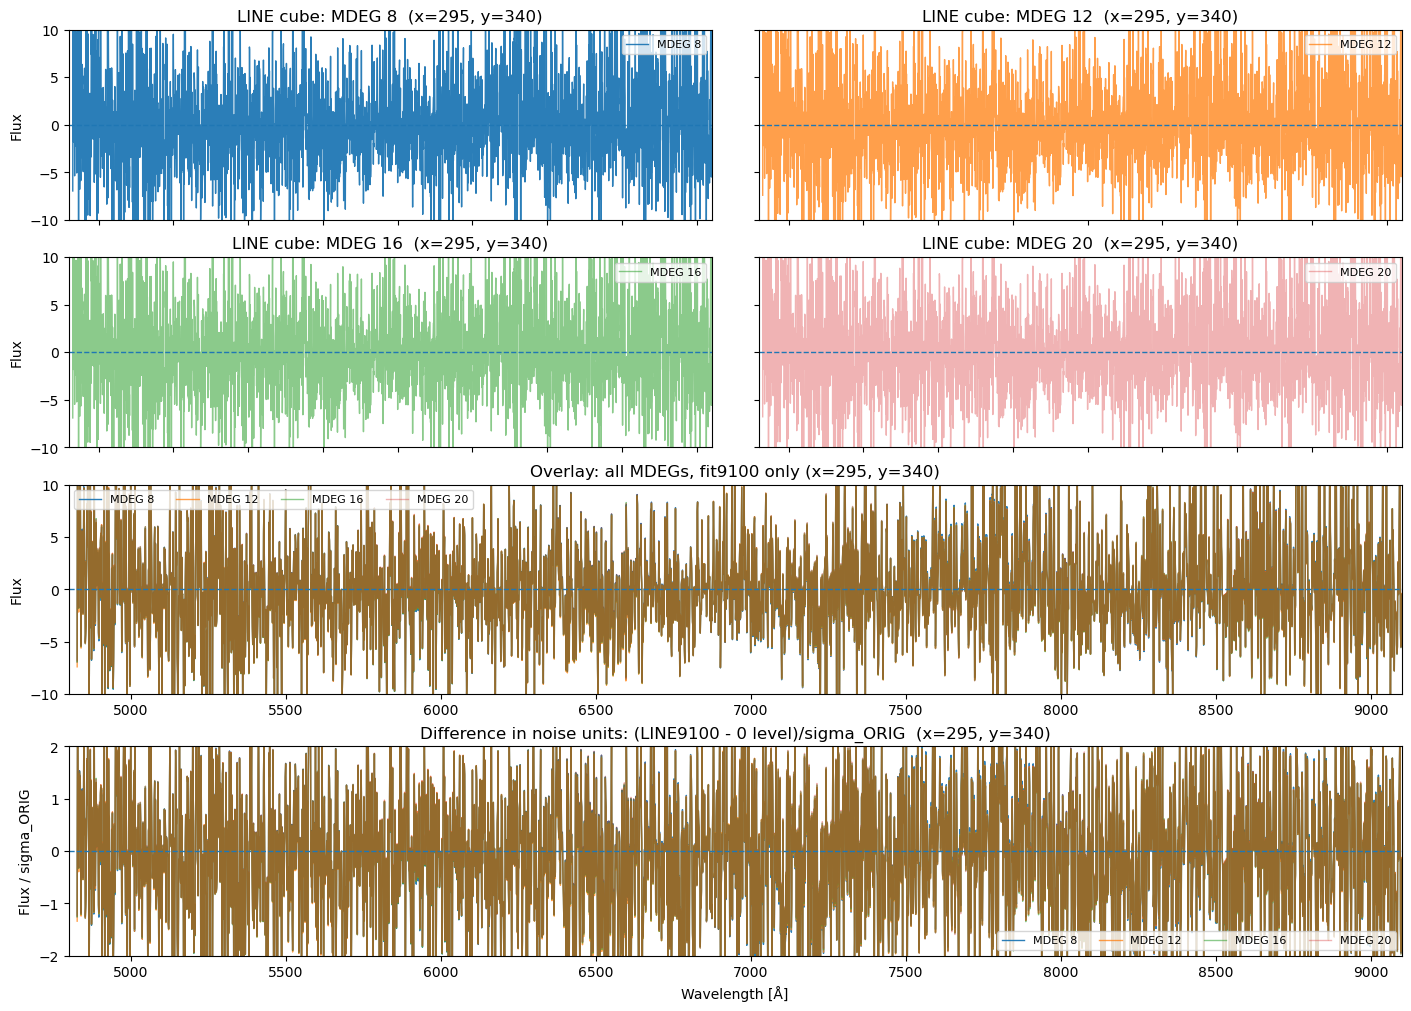

In [2]:
from pathlib import Path
import os
import warnings
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings("ignore", message="All-NaN slice encountered", category=RuntimeWarning)

# -----------------------------
# USER SETTINGS
# -----------------------------
base = Path.cwd()

run_ids_9100 = {
    8:  "IC3392_v3tk_9100_mask_uptoCONT_MDEG8",
    12: "IC3392_v3tk_9100_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_9100_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_9100_mask_uptoCONT_MDEG20",
}

run_ids_7000 = {
    8:  "IC3392_v3tk_mask_uptoCONT",
    12: "IC3392_v3tk_mask_uptoCONT_MDEG12",
    16: "IC3392_v3tk_mask_uptoCONT_MDEG16",
    20: "IC3392_v3tk_mask_uptoCONT_MDEG20",
}

if sorted(run_ids_9100) != sorted(run_ids_7000):
    raise ValueError("MDEG keys mismatch between 9100 and 7000 datasets")

MDEGS = sorted(run_ids_9100)
run_ids = run_ids_9100  # keep legacy name for later cells

linecube_name = lambda rid: base / rid / f"{rid}_line_cube.fits"

ORIG_CUBE_PATH = Path("/Users/Igniz/nGISTENV/ngist_supplementary_public/ngistTutorial/inputData/IC3392_DATACUBE_FINAL_WCS_Pall_mad_red_v3tk.fits")

windows = {
    "cont_5050_5120": (5050.0, 5120.0),
    "cont_5218_5485": (5218.0, 5485.0),
    "cont_5600_5650": (5600.0, 5650.0),
    "cont_6000_6200": (6000.0, 6200.0),
    "cont_6400_6500": (6400.0, 6500.0),
    "Hb_edge_4800_4920": (4800.0, 4920.0),
    "OIII_edge_4940_5060": (4940.0, 5060.0),
    "HaNII_edge_6500_6625": (6500.0, 6625.0),
    "SII_edge_6680_6760": (6680.0, 6760.0),
}

NSAMPLE  = 100000
STRIDE   = 4
NCPU     = min(os.cpu_count() or 8, 16)
DENOM_FLOOR_FRAC = 1e-3
CONT_FLOOR_FRAC = 1e-3
CONT_WIN = (5218.0, 5485.0)


# -----------------------------
# FITS HELPERS
# -----------------------------
def wave_from_fits_header(hdr):
    crval = hdr["CRVAL3"]
    cdelt = hdr.get("CDELT3", hdr.get("CD3_3"))
    crpix = hdr.get("CRPIX3", 1.0)
    n = hdr["NAXIS3"]
    pix = np.arange(n) + 1
    return crval + (pix - crpix) * cdelt

def open_memmap_cube(path):
    hdul = fits.open(path, memmap=True)
    cube = hdul[0].data
    wave = wave_from_fits_header(hdul[0].header)
    return hdul, cube, wave

def open_memmap_cube_anyhdu(path: Path):
    hdul = fits.open(path, memmap=True)
    hdu = None
    for hh in hdul:
        if getattr(hh, "data", None) is None:
            continue
        if hh.data is None:
            continue
        if hh.data.ndim == 3 and hh.name.upper() != "STAT":
            hdu = hh
            break
    if hdu is None:
        raise RuntimeError(f"No 3D flux cube found in {path}")

    if "STAT" not in hdul:
        raise RuntimeError(f"STAT extension not found in {path}")
    stat_hdu = hdul["STAT"]
    if getattr(stat_hdu, "data", None) is None or stat_hdu.data.ndim != 3:
        raise RuntimeError(f"STAT extension is not a 3D variance cube in {path}")

    cube = hdu.data
    var_cube = stat_hdu.data
    wave = wave_from_fits_header(hdu.header)
    return hdul, cube, var_cube, wave

def continuum_level_map(cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Continuum window has no samples on this wavelength grid.")
    return np.nanmedian(cube[idx, :, :], axis=0)

def noise_level_map(var_cube, wave, w1, w2):
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        raise RuntimeError("Noise window has no samples on this wavelength grid.")
    med_var = np.nanmedian(var_cube[idx, :, :], axis=0)
    return np.sqrt(np.clip(med_var, 0.0, None))

def interp_spec_to_wave(spec_in, wave_in, wave_out):
    ok = np.isfinite(spec_in) & np.isfinite(wave_in)
    if ok.sum() < 2:
        return np.full_like(wave_out, np.nan, dtype=float)
    return np.interp(wave_out, wave_in[ok], spec_in[ok], left=np.nan, right=np.nan)


def load_dataset(run_map, label):
    hduls, cubes, waves = {}, {}, {}
    for mdeg, rid in run_map.items():
        f = linecube_name(rid)
        hdul, cube, wave = open_memmap_cube(f)
        hduls[mdeg] = hdul
        cubes[mdeg] = cube
        waves[mdeg] = wave
        print(f"[LOAD {label}] MDEG={mdeg:>2}  file={f.name}  shape={cube.shape}")

    ref_spatial = cubes[MDEGS[0]].shape[1:]
    for mdeg in MDEGS:
        if cubes[mdeg].shape[1:] != ref_spatial:
            raise ValueError(f"{label}: spatial shape mismatch at MDEG {mdeg}: {cubes[mdeg].shape[1:]} vs {ref_spatial}")
    return hduls, cubes, waves[MDEGS[0]], ref_spatial


# -----------------------------
# LOAD BOTH FITTING-RANGE DATASETS
# -----------------------------
hduls_9100, cubes_9100, wave_9100, spatial_9100 = load_dataset(run_ids_9100, "9100")
hduls_7000, cubes_7000, wave_7000, spatial_7000 = load_dataset(run_ids_7000, "7000")

if spatial_9100 != spatial_7000:
    raise ValueError("Cross-range spatial shape mismatch between 9100 and 7000 datasets")

if not np.allclose(wave_9100[: min(len(wave_9100), len(wave_7000))], wave_7000[: min(len(wave_9100), len(wave_7000))], atol=1e-6, rtol=0):
    print("[WARN] wavelength grids differ; interpolation will be used where direct subtraction is needed")

ref_wave = wave_7000

datasets = {
    "9100": {"hduls": hduls_9100, "cubes": cubes_9100, "wave": wave_9100},
    "7000": {"hduls": hduls_7000, "cubes": cubes_7000, "wave": wave_7000},
}

# legacy aliases retained for downstream cells
hduls = hduls_9100
cubes = cubes_9100

# Load ORIGINAL flux cube + STAT variance cube
hdul_orig, cube_orig, var_orig, wave_orig = open_memmap_cube_anyhdu(ORIG_CUBE_PATH)
print(f"[LOAD ORIG] {ORIG_CUBE_PATH.name}  shape={cube_orig.shape}")

if cube_orig.shape[1:] != spatial_9100:
    raise ValueError(f"ORIG cube spatial shape mismatch: {cube_orig.shape[1:]} vs {spatial_9100}")
if var_orig.shape != cube_orig.shape:
    raise ValueError(f"STAT variance shape mismatch: {var_orig.shape} vs {cube_orig.shape}")

cont_map = continuum_level_map(cube_orig, wave_orig, *CONT_WIN)
cont_finite = np.isfinite(cont_map)
cont_scale = np.nanpercentile(np.abs(cont_map[cont_finite]), 90)
CONT_FLOOR = cont_scale * CONT_FLOOR_FRAC
print(f"[CONT] p90(|cont|)={cont_scale:.4g}, floor={CONT_FLOOR:.4g}")

noise_map = noise_level_map(var_orig, wave_orig, *CONT_WIN)
noise_finite = np.isfinite(noise_map)
noise_scale = np.nanpercentile(noise_map[noise_finite], 50)
print(f"[NOISE] median sigma({CONT_WIN[0]:.0f}-{CONT_WIN[1]:.0f})={noise_scale:.4g}")


# -----------------------------
# BUILD RANDOM SPAXEL SAMPLE (valid in both ranges)
# -----------------------------
w1_ref, w2_ref = windows["cont_5218_5485"]
idx_ref_9100 = (wave_9100 >= w1_ref) & (wave_9100 <= w2_ref)
idx_ref_7000 = (wave_7000 >= w1_ref) & (wave_7000 <= w2_ref)

sub_9100_ref = cubes_9100[MDEGS[0]][idx_ref_9100, :, :]
sub_7000_ref = cubes_7000[MDEGS[0]][idx_ref_7000, :, :]
valid_ref = np.isfinite(sub_9100_ref).any(axis=0) & np.isfinite(sub_7000_ref).any(axis=0)

yy, xx = np.where(valid_ref)
n_valid = yy.size
if n_valid == 0:
    raise RuntimeError("No valid spaxels found in both ranges for the reference window")

rng = np.random.default_rng(42)
take = min(NSAMPLE, n_valid)
sel_idx = rng.choice(n_valid, size=take, replace=False)
ys = yy[sel_idx]
xs = xx[sel_idx]
print(f"[SAMPLE] Using {take} spaxels out of {n_valid} jointly-valid spaxels")
print(f"[PARALLEL] Using {NCPU} threads")

cont_samp = cont_map[ys, xs]
cont_samp_denom = np.sign(cont_samp) * np.maximum(np.abs(cont_samp), CONT_FLOOR)
noise_samp = noise_map[ys, xs]


# -----------------------------
# STATS HELPERS (PER RANGE, PER MDEG)
# -----------------------------
def compute_window_stats_for_dataset(dataset_key, mdeg, w1, w2):
    cube = datasets[dataset_key]["cubes"][mdeg]
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return dataset_key, mdeg, None, np.full(take, np.nan), np.full(take, np.nan)

    slab = cube[idx, :, :]
    sub = slab[:, ys, xs]

    valid = np.isfinite(sub).any(axis=0)
    med_all = np.full(take, np.nan, dtype=float)
    rms_all = np.full(take, np.nan, dtype=float)

    if valid.sum() == 0:
        return dataset_key, mdeg, {"n_valid": 0, "n_tot": int(valid.size)}, med_all, rms_all

    subv = sub[:, valid]
    med = np.nanmedian(subv, axis=0)
    mad = np.nanmedian(np.abs(subv - med[None, :]), axis=0)
    rms = 1.4826 * mad

    med_all[valid] = med
    rms_all[valid] = rms

    stats = {
        "n_valid": int(valid.sum()),
        "n_tot": int(valid.size),
        "med_p16": float(np.nanpercentile(med, 16)),
        "med_p50": float(np.nanpercentile(med, 50)),
        "med_p84": float(np.nanpercentile(med, 84)),
        "rms_p16": float(np.nanpercentile(rms, 16)),
        "rms_p50": float(np.nanpercentile(rms, 50)),
        "rms_p84": float(np.nanpercentile(rms, 84)),
    }
    return dataset_key, mdeg, stats, med_all, rms_all


def window_rms_map(dataset_key, mdeg, w1, w2, stride=4):
    wave = datasets[dataset_key]["wave"]
    idx = (wave >= w1) & (wave <= w2)
    if not np.any(idx):
        return None
    slab = datasets[dataset_key]["cubes"][mdeg][idx, ::stride, ::stride]
    med = np.nanmedian(slab, axis=0)
    mad = np.nanmedian(np.abs(slab - med[None, :, :]), axis=0)
    return 1.4826 * mad


# # -----------------------------
# # MAIN WINDOW LOOP: (9100 - 7000) at fixed MDEG
# # -----------------------------
# for wname, (w1, w2) in windows.items():
#     print("\n" + "=" * 90)
#     print(f"WINDOW: {wname}  ({w1:.1f}–{w2:.1f} Å)")

#     stats_by = {"9100": {}, "7000": {}}
#     med_by = {"9100": {}, "7000": {}}
#     rms_by = {"9100": {}, "7000": {}}

#     with ThreadPoolExecutor(max_workers=NCPU) as ex:
#         futures = [
#             ex.submit(compute_window_stats_for_dataset, dk, mdeg, w1, w2)
#             for dk in ("9100", "7000")
#             for mdeg in MDEGS
#         ]
#         for fut in as_completed(futures):
#             dk, mdeg, stats, med_all, rms_all = fut.result()
#             stats_by[dk][mdeg] = stats
#             med_by[dk][mdeg] = med_all
#             rms_by[dk][mdeg] = rms_all

#     print("\n  Absolute summaries by fitting range:")
#     for mdeg in MDEGS:
#         for dk in ("9100", "7000"):
#             s = stats_by[dk][mdeg]
#             if s is None or s.get("n_valid", 0) == 0:
#                 print(f"    MDEG={mdeg:>2} [{dk}]: no valid sampled spaxels")
#                 continue
#             print(
#                 f"    MDEG={mdeg:>2} [{dk}]: "
#                 f"med=({s['med_p16']:.4g},{s['med_p50']:.4g},{s['med_p84']:.4g})  "
#                 f"rms=({s['rms_p16']:.4g},{s['rms_p50']:.4g},{s['rms_p84']:.4g})  "
#                 f"N={s['n_valid']}/{s['n_tot']}"
#             )

#     print("\n  Cross-fitting-range comparison (9100 - 7000) at fixed MDEG:")
#     drms_pct_by_mdeg = {}
#     dmed_by_mdeg = {}

#     for mdeg in MDEGS:
#         med9100 = med_by["9100"][mdeg]
#         med7000 = med_by["7000"][mdeg]
#         rms9100 = rms_by["9100"][mdeg]
#         rms7000 = rms_by["7000"][mdeg]

#         ok = np.isfinite(med9100) & np.isfinite(med7000) & np.isfinite(rms9100) & np.isfinite(rms7000)
#         if ok.sum() == 0:
#             print(f"    MDEG={mdeg:>2}: no overlap-valid spaxels")
#             drms_pct_by_mdeg[mdeg] = np.array([])
#             dmed_by_mdeg[mdeg] = np.array([])
#             continue

#         dmed = med9100[ok] - med7000[ok]
#         drms = rms9100[ok] - rms7000[ok]

#         denom_ok = np.isfinite(rms7000[ok]) & (rms7000[ok] > 0)
#         if denom_ok.any():
#             floor = np.nanpercentile(rms7000[ok][denom_ok], 5) * DENOM_FLOOR_FRAC
#             denom = np.maximum(rms7000[ok], floor)
#             drms_pct = drms / denom * 100.0
#         else:
#             drms_pct = np.full(ok.sum(), np.nan)

#         dmed_by_mdeg[mdeg] = dmed
#         drms_pct_by_mdeg[mdeg] = drms_pct[np.isfinite(drms_pct)]

#         p16m, p50m, p84m = np.nanpercentile(dmed, [16, 50, 84])
#         p16r, p50r, p84r = np.nanpercentile(drms, [16, 50, 84])
#         print(
#             f"    MDEG={mdeg:>2}: ΔMED=(p16,p50,p84)=({p16m:.3g},{p50m:.3g},{p84m:.3g})  "
#             f"ΔRMS(abs)=({p16r:.3g},{p50r:.3g},{p84r:.3g})"
#         )

#         if drms_pct_by_mdeg[mdeg].size > 0:
#             p16, p50, p84 = np.nanpercentile(drms_pct_by_mdeg[mdeg], [16, 50, 84])
#             print(f"              ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000: ({p16:.3g}, {p50:.3g}, {p84:.3g})")

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = drms_pct_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"ΔRMS[%] between fitting ranges (9100-7000): {wname}")
    # plt.xlabel("100*(RMS9100 - RMS7000) / RMS7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # plt.figure(figsize=(8, 4))
    # for mdeg in MDEGS:
    #     arr = dmed_by_mdeg.get(mdeg, np.array([]))
    #     if arr.size == 0:
    #         continue
    #     plt.hist(arr, bins=80, histtype="step", density=True, label=f"MDEG {mdeg}")
    # plt.axvline(0, ls="--", lw=1)
    # plt.title(f"Δ median residual (9100-7000): {wname}")
    # plt.xlabel("Median9100 - Median7000")
    # plt.ylabel("PDF (normalized)")
    # plt.legend()
    # plt.show()

    # for mdeg in MDEGS:
    #     rms_9100_map = window_rms_map("9100", mdeg, w1, w2, stride=STRIDE)
    #     rms_7000_map = window_rms_map("7000", mdeg, w1, w2, stride=STRIDE)

    #     if rms_9100_map is None or rms_7000_map is None:
    #         continue

    #     finite_7000 = np.isfinite(rms_7000_map) & (rms_7000_map > 0)
    #     if not finite_7000.any():
    #         continue

    #     floor = np.nanpercentile(rms_7000_map[finite_7000], 5) * DENOM_FLOOR_FRAC
    #     denom = np.maximum(rms_7000_map, floor)
    #     pct_map = (rms_9100_map - rms_7000_map) / denom * 100.0

    #     finite = np.isfinite(pct_map)
    #     v = np.nanpercentile(np.abs(pct_map[finite]), 99) if finite.any() else 10.0

    #     plt.figure(figsize=(6, 5))
    #     plt.imshow(pct_map, origin="lower", vmin=-v, vmax=v)
    #     plt.colorbar(label=f"ΔRMS[%] = 100*(RMS9100-RMS7000)/RMS7000  (MDEG={mdeg}, stride={STRIDE})")
    #     plt.title(f"% RMS-change map (9100-7000): {wname}, MDEG={mdeg}")
    #     plt.xlabel("x [pix/stride]")
    #     plt.ylabel("y [pix/stride]")
    #     plt.show()


# -----------------------------
# SPAXEL SPECTRUM OVERLAY (x,y from Mapviewer)
# -----------------------------
# Updated plotting: show spectra up to 9100 and use LINE9100-only noise-normalized panel
XPIX = 295
YPIX = 340

def plot_spaxel_suite(
    x, y,
    mdegs=(8, 12, 16, 20),
    wmin=4800,
    wmax=9100,
):
    w9100 = wave_9100
    sel9100 = (w9100 >= wmin) & (w9100 <= wmax)

    mdegs = tuple(mdegs)
    mmin, mmax = min(mdegs), max(mdegs)

    def alpha_for_mdeg(m, a_hi=0.95, a_lo=0.35):
        # higher MDEG -> lower alpha
        if mmax == mmin:
            return 0.8
        t = (m - mmin) / (mmax - mmin)
        return a_hi - t * (a_hi - a_lo)

    # consistent color per MDEG across all panels
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle_colors:
        cycle_colors = [f"C{i}" for i in range(10)]
    mdeg_sorted = sorted(mdegs)
    color_map = {m: cycle_colors[i % len(cycle_colors)] for i, m in enumerate(mdeg_sorted)}

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = GridSpec(nrows=4, ncols=2, figure=fig, height_ratios=[1, 1, 1.1, 1.1])

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
    ax10 = fig.add_subplot(gs[1, 0], sharey=ax00)
    ax11 = fig.add_subplot(gs[1, 1], sharey=ax00)
    axes_ind = [ax00, ax01, ax10, ax11]

    ax_overlay = fig.add_subplot(gs[2, :], sharex=ax00)
    ax_diff = fig.add_subplot(gs[3, :], sharex=ax00)

    # --- Individual panels: each MDEG (9100 only) ---
    for ax, mdeg in zip(axes_ind, mdegs):
        s9100 = cubes_9100[mdeg][:, y, x]
        g9100 = sel9100 & np.isfinite(s9100)

        ax.plot(
            w9100[g9100], s9100[g9100],
            lw=1,
            color=color_map[mdeg],
            alpha=alpha_for_mdeg(mdeg),
            label=f"MDEG {mdeg}"
        )
        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"LINE cube: MDEG {mdeg}  (x={x}, y={y})")
        ax.set_ylabel("Flux")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_xlim(wmin, wmax)
        ax.set_ylim(-10, 10)

    for ax in axes_ind:
        ax.label_outer()

    # --- Overlay panel: all MDEGs (9100 only) ---
    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        g9100 = sel9100 & np.isfinite(s9100)
        ax_overlay.plot(
            w9100[g9100], s9100[g9100],
            lw=1,
            color=color_map[mdeg],
            alpha=alpha_for_mdeg(mdeg),
            label=f"MDEG {mdeg}"
        )

    ax_overlay.axhline(0, ls="--", lw=1)
    ax_overlay.set_title(f"Overlay: all MDEGs, fit9100 only (x={x}, y={y})")
    ax_overlay.set_ylabel("Flux")
    ax_overlay.legend(ncol=4, fontsize=8, loc="upper left")
    ax_overlay.set_xlim(wmin, wmax)
    ax_overlay.set_ylim(-10, 10)

    # --- Bottom panel: (LINE9100 - 0)/sigma_ORIG ---
    sigma0 = np.sqrt(np.clip(var_orig[:, y, x], 0.0, None))          # on wave_orig
    sigma0_on_9100 = interp_spec_to_wave(sigma0, wave_orig, w9100)   # onto wave_9100

    finite = np.isfinite(sigma0_on_9100)
    if finite.any():
        sigma_floor = np.nanpercentile(sigma0_on_9100[finite], 5) * 1e-3
        if not np.isfinite(sigma_floor) or sigma_floor <= 0:
            sigma_floor = 1e-12
    else:
        sigma_floor = 1e-12

    sigma_denom = np.where(
        np.isfinite(sigma0_on_9100),
        np.maximum(sigma0_on_9100, sigma_floor),
        np.nan
    )

    for mdeg in mdegs:
        s9100 = cubes_9100[mdeg][:, y, x]
        d_over_noise = s9100 / sigma_denom
        good = sel9100 & np.isfinite(d_over_noise)
        if good.any():
            ax_diff.plot(
                w9100[good], d_over_noise[good],
                lw=1,
                color=color_map[mdeg],
                alpha=alpha_for_mdeg(mdeg),
                label=f"MDEG {mdeg}"
            )

    ax_diff.axhline(0, ls="--", lw=1)
    ax_diff.set_title(f"Difference in noise units: (LINE9100 - 0 level)/sigma_ORIG  (x={x}, y={y})")
    ax_diff.set_xlabel("Wavelength [Å]")
    ax_diff.set_ylabel("Flux / sigma_ORIG")
    ax_diff.set_xlim(wmin, wmax)
    ax_diff.set_ylim(-2, 2)
    ax_diff.legend(ncol=min(4, len(mdegs)), loc="lower right", fontsize=8)

    plt.show()


plot_spaxel_suite(XPIX, YPIX, mdegs=(8, 12, 16, 20), wmin=4800, wmax=9100)

[EBV] finite spaxels: full=71984, stride=71984
[GLOBAL] MDEG 8: computed over EBV-valid spaxels with STRIDE=1, N=71984, nw=3419
[GLOBAL] MDEG 12: computed over EBV-valid spaxels with STRIDE=1, N=71984, nw=3419
[GLOBAL] MDEG 16: computed over EBV-valid spaxels with STRIDE=1, N=71984, nw=3419
[GLOBAL] MDEG 20: computed over EBV-valid spaxels with STRIDE=1, N=71984, nw=3419


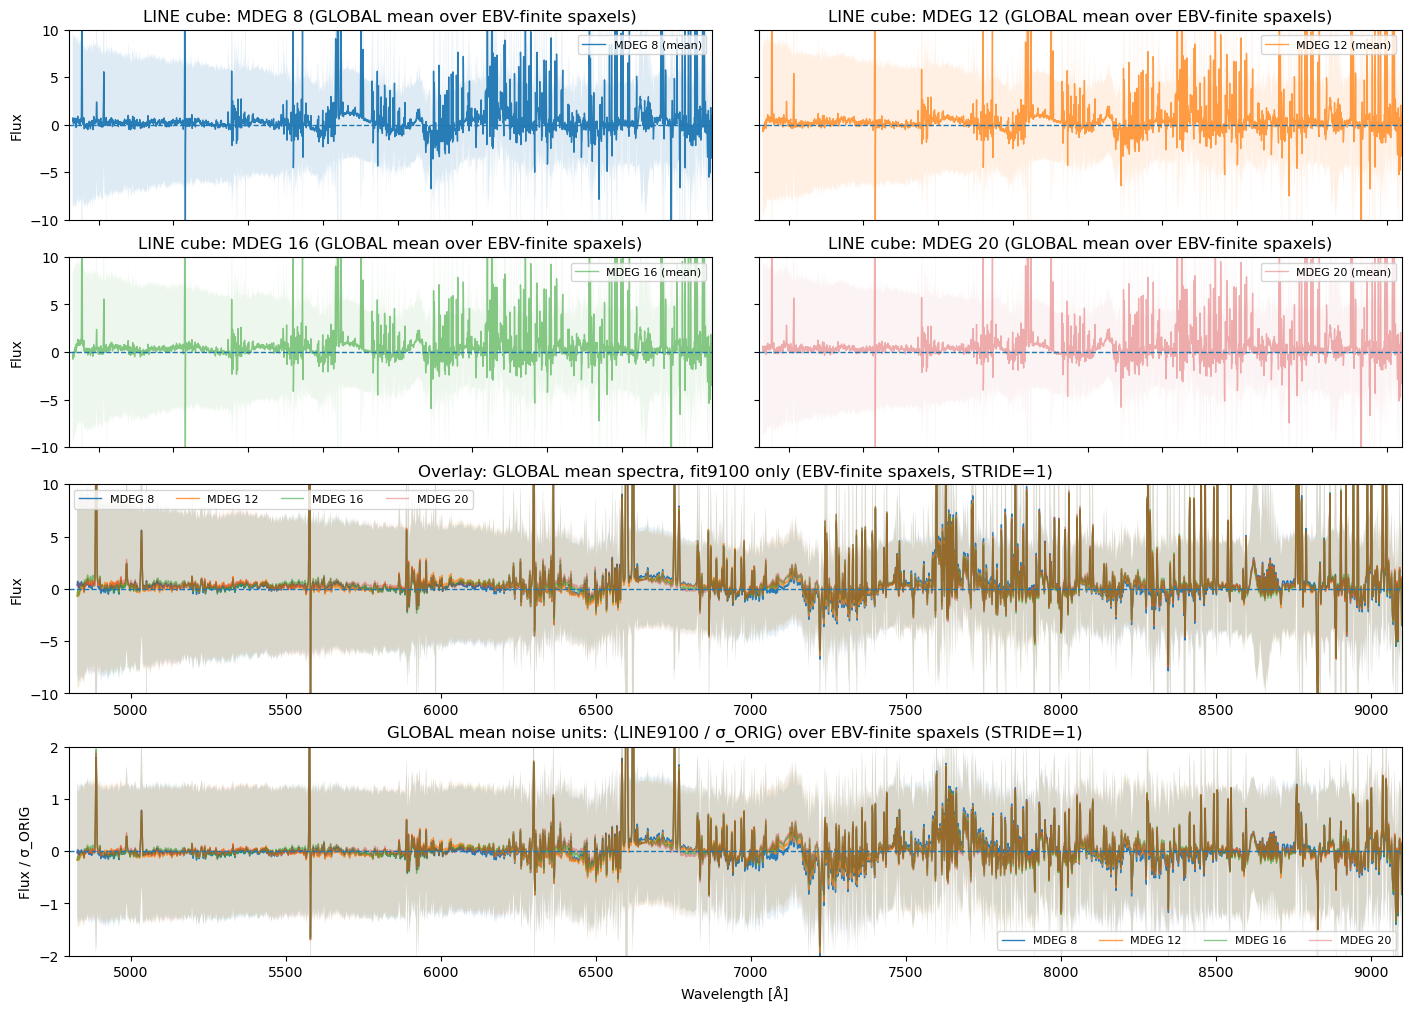

In [3]:
# ============================
# Cell 1: Global-spectrum settings
# ============================

WMIN, WMAX = 4800.0, 9100.0

# Use STRIDE=1 for truly all spaxels. Use 2 or 4 for a fast "whole-cube" proxy.
STRIDE_GLOBAL = 1

# Block size along wavelength to avoid big temporary arrays
WBLOCK = 128

# Show ±1σ(spaxels) band?
SHOW_BAND = True

# Only use spaxels with finite EBV in this map
EBV_KIN_MAPS_PATH = Path("/Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/IC3392_v3tk_9100_mask_uptoCONT_MDEG8/IC3392_v3tk_9100_mask_uptoCONT_MDEG8_kin_maps.fits")

# ============================
# Cell 2: Prepare variance -> sigma mapping from wave_orig to wave_9100
# ============================

# indices for plotting range
sel9100 = (wave_9100 >= WMIN) & (wave_9100 <= WMAX)
w = wave_9100[sel9100]
nw = w.size

# Build linear interpolation indices from wave_orig -> wave_9100
# (works even if grids differ; avoids per-spaxel np.interp loops)
wo = wave_orig
if not (np.all(np.diff(wo) > 0) and np.all(np.diff(w) > 0)):
    raise RuntimeError("wave_orig and/or wave_9100 not strictly increasing.")

j = np.searchsorted(wo, w, side="left")
j = np.clip(j, 1, len(wo)-1)
j0 = j - 1
j1 = j

x0 = wo[j0]
x1 = wo[j1]
t = (w - x0) / (x1 - x0)
t = t.astype(np.float32)  # small memory

def sigma_orig_on_w_block(i0, i1, stride=1):
    """
    Return sigma_ORIG (sqrt(var)) on wave_9100[sel9100][i0:i1] for spatial grid [::stride, ::stride].
    Uses linear interpolation of VARIANCE along wavelength axis.
    """
    jj0 = j0[i0:i1]
    jj1 = j1[i0:i1]
    tt  = t[i0:i1].reshape(-1, 1, 1)

    v0 = var_orig[jj0, ::stride, ::stride]
    v1 = var_orig[jj1, ::stride, ::stride]
    v  = (1.0 - tt) * v0 + tt * v1

    sig = np.sqrt(np.clip(v, 0.0, None))

    # floor to avoid divide-by-zero
    finite = np.isfinite(sig) & (sig > 0)
    if finite.any():
        floor = np.nanpercentile(sig[finite], 5) * 1e-3
        if not np.isfinite(floor) or floor <= 0:
            floor = 1e-12
    else:
        floor = 1e-12

    return np.maximum(sig, floor)

# ============================
# Cell 2b: Build EBV-valid spaxel mask
# ============================
with fits.open(EBV_KIN_MAPS_PATH, memmap=True) as hdul_kin:
    if "EBV" not in hdul_kin:
        raise RuntimeError(f"EBV extension not found in {EBV_KIN_MAPS_PATH}")
    ebv_map = hdul_kin["EBV"].data

if ebv_map is None or ebv_map.ndim != 2:
    raise RuntimeError("EBV HDU is missing or not 2D")

ref_spatial = cubes_9100[MDEGS[0]].shape[1:]
if ebv_map.shape != ref_spatial:
    raise RuntimeError(f"EBV map shape mismatch: {ebv_map.shape} vs {ref_spatial}")

valid_spaxel_mask_full = np.isfinite(ebv_map)
n_valid_full = int(valid_spaxel_mask_full.sum())
if n_valid_full == 0:
    raise RuntimeError("No finite spaxels found in EBV map")

valid_spaxel_mask = valid_spaxel_mask_full[::STRIDE_GLOBAL, ::STRIDE_GLOBAL]
n_valid_stride = int(valid_spaxel_mask.sum())
if n_valid_stride == 0:
    raise RuntimeError("No EBV-valid spaxels remain after applying STRIDE_GLOBAL")

print(f"[EBV] finite spaxels: full={n_valid_full}, stride={n_valid_stride}")

# ============================
# Cell 3: Compute global mean/std spectra for each MDEG (block-wise, EBV-valid spaxels only)
# ============================

global_specs = {}

for mdeg in MDEGS:
    # allocate outputs on the selected wavelength grid
    mean_flux = np.full(nw, np.nan, dtype=np.float64)
    std_flux  = np.full(nw, np.nan, dtype=np.float64)

    mean_z = np.full(nw, np.nan, dtype=np.float64)   # z = LINE / sigma_ORIG
    std_z  = np.full(nw, np.nan, dtype=np.float64)

    cube = cubes_9100[mdeg]  # memmap

    # loop in wavelength blocks to keep memory small
    for i0 in range(0, nw, WBLOCK):
        i1 = min(i0 + WBLOCK, nw)

        # slice corresponding indices in full wave_9100 cube
        idx_full = np.where(sel9100)[0][i0:i1]   # indices into cube spectral axis

        flux_blk = cube[idx_full, ::STRIDE_GLOBAL, ::STRIDE_GLOBAL]  # (nb, ny, nx)
        flux_vals = flux_blk[:, valid_spaxel_mask]                    # (nb, n_valid)

        # mean/std across EBV-valid spaxels for each wavelength
        mean_flux[i0:i1] = np.nanmean(flux_vals, axis=1)
        std_flux[i0:i1]  = np.nanstd(flux_vals,  axis=1)

        # sigma block on matching wavelengths (already restricted to sel9100)
        sig_blk = sigma_orig_on_w_block(i0, i1, stride=STRIDE_GLOBAL)
        sig_vals = sig_blk[:, valid_spaxel_mask]

        z_blk = flux_vals / sig_vals
        mean_z[i0:i1] = np.nanmean(z_blk, axis=1)
        std_z[i0:i1]  = np.nanstd(z_blk,  axis=1)

    global_specs[mdeg] = {
        "w": w,
        "mean_flux": mean_flux, "std_flux": std_flux,
        "mean_z": mean_z,       "std_z": std_z,
    }

    print(f"[GLOBAL] MDEG {mdeg}: computed over EBV-valid spaxels with STRIDE={STRIDE_GLOBAL}, N={n_valid_stride}, nw={nw}")

# ============================
# Cell 4: Plot global mean spectra (same layout)
# ============================

def plot_global_suite(mdegs=(8, 12, 16, 20), ylim_z=(-2, 2), show_band=True):
    mdegs = tuple(mdegs)
    mmin, mmax = min(mdegs), max(mdegs)

    def alpha_for_mdeg(m, a_hi=0.95, a_lo=0.35):
        if mmax == mmin:
            return 0.8
        t_ = (m - mmin) / (mmax - mmin)
        return a_hi - t_ * (a_hi - a_lo)

    # consistent color per MDEG
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle_colors:
        cycle_colors = [f"C{i}" for i in range(10)]
    mdeg_sorted = sorted(mdegs)
    color_map = {m: cycle_colors[i % len(cycle_colors)] for i, m in enumerate(mdeg_sorted)}

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = GridSpec(nrows=4, ncols=2, figure=fig, height_ratios=[1, 1, 1.1, 1.1])

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
    ax10 = fig.add_subplot(gs[1, 0], sharey=ax00)
    ax11 = fig.add_subplot(gs[1, 1], sharey=ax00)
    axes_ind = [ax00, ax01, ax10, ax11]

    ax_overlay = fig.add_subplot(gs[2, :], sharex=ax00)
    ax_z = fig.add_subplot(gs[3, :], sharex=ax00)

    w = global_specs[mdegs[0]]["w"]

    # --- Individual panels ---
    for ax, mdeg in zip(axes_ind, mdegs):
        s = global_specs[mdeg]["mean_flux"]
        e = global_specs[mdeg]["std_flux"]
        a = alpha_for_mdeg(mdeg)

        ax.plot(w, s, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg} (mean)")
        if show_band:
            ax.fill_between(w, s - e, s + e, color=color_map[mdeg], alpha=0.15 * a, linewidth=0)

        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"LINE cube: MDEG {mdeg} (GLOBAL mean over EBV-finite spaxels)")
        ax.set_ylabel("Flux")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_xlim(WMIN, WMAX)
        ax.set_ylim(-10, 10)

    for ax in axes_ind:
        ax.label_outer()

    # --- Overlay ---
    for mdeg in mdegs:
        s = global_specs[mdeg]["mean_flux"]
        e = global_specs[mdeg]["std_flux"]
        a = alpha_for_mdeg(mdeg)

        ax_overlay.plot(w, s, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg}")
        if show_band:
            ax_overlay.fill_between(w, s - e, s + e, color=color_map[mdeg], alpha=0.12 * a, linewidth=0)

    ax_overlay.axhline(0, ls="--", lw=1)
    ax_overlay.set_title(f"Overlay: GLOBAL mean spectra, fit9100 only (EBV-finite spaxels, STRIDE={STRIDE_GLOBAL})")
    ax_overlay.set_ylabel("Flux")
    ax_overlay.legend(ncol=4, fontsize=8, loc="upper left")
    ax_overlay.set_xlim(WMIN, WMAX)
    ax_overlay.set_ylim(-10, 10)

    # --- Bottom panel: GLOBAL mean z = LINE/sigma_ORIG ---
    for mdeg in mdegs:
        z = global_specs[mdeg]["mean_z"]
        ez = global_specs[mdeg]["std_z"]
        a = alpha_for_mdeg(mdeg)

        ax_z.plot(w, z, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg}")
        if show_band:
            ax_z.fill_between(w, z - ez, z + ez, color=color_map[mdeg], alpha=0.12 * a, linewidth=0)

    ax_z.axhline(0, ls="--", lw=1)
    ax_z.set_title(f"GLOBAL mean noise units: ⟨LINE9100 / σ_ORIG⟩ over EBV-finite spaxels (STRIDE={STRIDE_GLOBAL})")
    ax_z.set_xlabel("Wavelength [Å]")
    ax_z.set_ylabel("Flux / σ_ORIG")
    ax_z.set_xlim(WMIN, WMAX)
    ax_z.set_ylim(*ylim_z)
    ax_z.legend(ncol=4, fontsize=8, loc="lower right")

    plt.show()


plot_global_suite(mdegs=(8, 12, 16, 20), ylim_z=(-2, 2), show_band=SHOW_BAND)

[CENTER] using 10x10 box centered at (218,218): full=100, stride=100
[GLOBAL] MDEG 8: computed over central 10x10 box (center=(218,218), STRIDE=1), N=100, nw=3419
[GLOBAL] MDEG 12: computed over central 10x10 box (center=(218,218), STRIDE=1), N=100, nw=3419
[GLOBAL] MDEG 16: computed over central 10x10 box (center=(218,218), STRIDE=1), N=100, nw=3419
[GLOBAL] MDEG 20: computed over central 10x10 box (center=(218,218), STRIDE=1), N=100, nw=3419


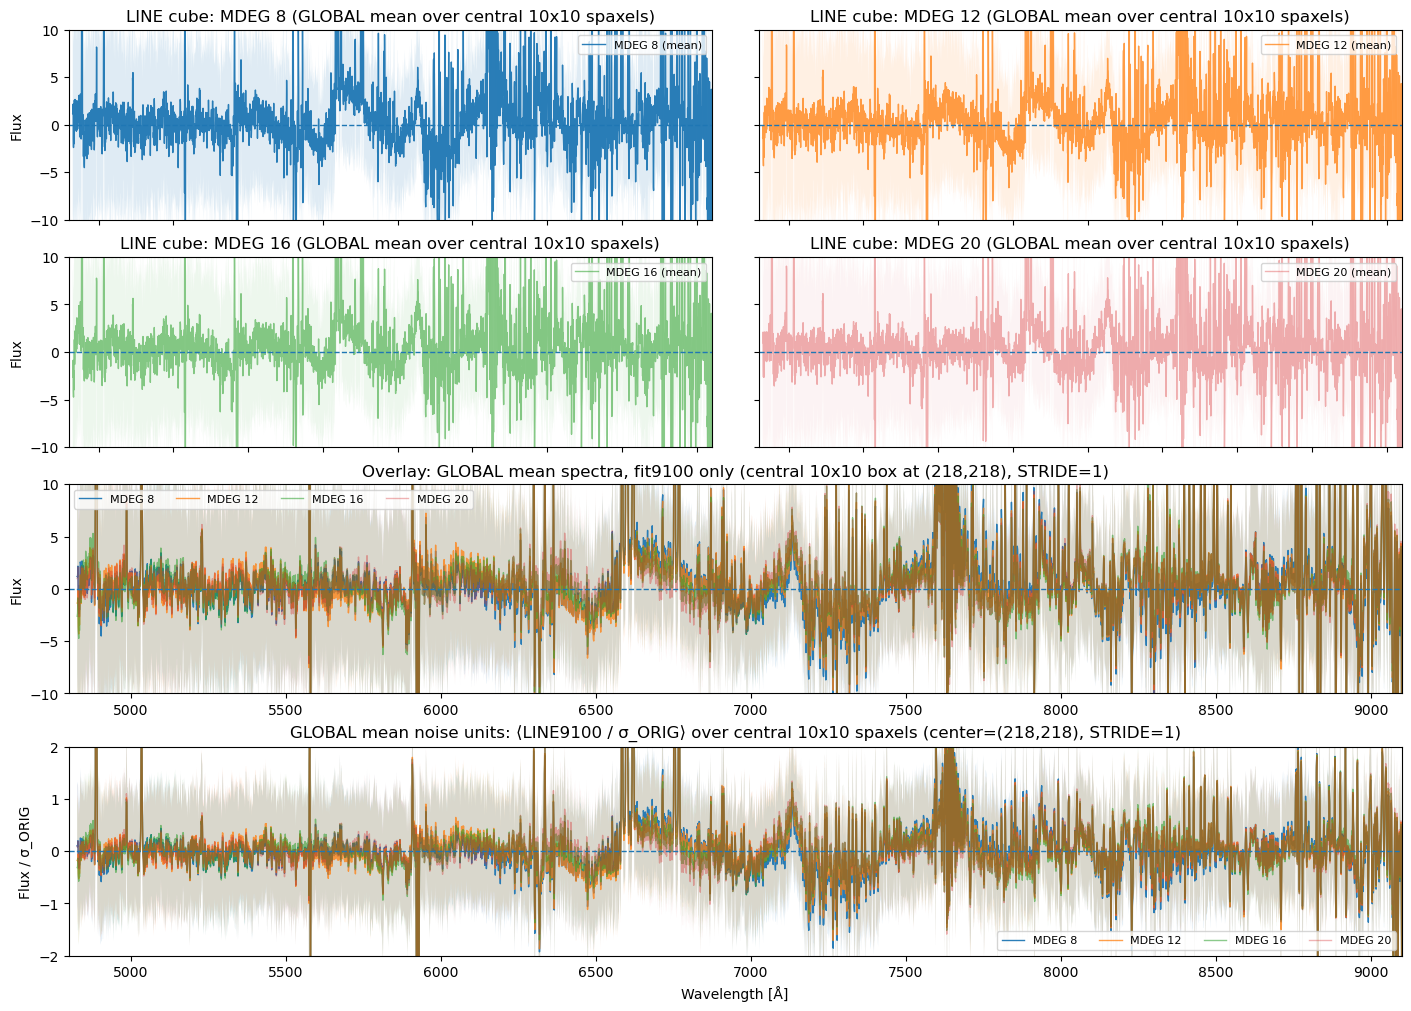

In [4]:
# ============================
# Cell 1: Global-spectrum settings
# ============================

WMIN, WMAX = 4800.0, 9100.0

# Use STRIDE=1 for truly all spaxels. Use 2 or 4 for a fast "whole-cube" proxy.
STRIDE_GLOBAL = 1

# Block size along wavelength to avoid big temporary arrays
WBLOCK = 128

# Show ±1σ(spaxels) band?
SHOW_BAND = True

# Use only the central 10x10 spaxels centered at (218, 218)
CENTER_X, CENTER_Y = 218, 218
CENTER_BOX = 10

# (kept for compatibility; not used in this cell anymore)
EBV_KIN_MAPS_PATH = Path("/Users/Igniz/Desktop/ICRAR/nGIST_dev_7.6.4/IC3392_v3tk_9100_mask_uptoCONT_MDEG8/IC3392_v3tk_9100_mask_uptoCONT_MDEG8_kin_maps.fits")

# ============================
# Cell 2: Prepare variance -> sigma mapping from wave_orig to wave_9100
# ============================

# indices for plotting range
sel9100 = (wave_9100 >= WMIN) & (wave_9100 <= WMAX)
w = wave_9100[sel9100]
nw = w.size

# Build linear interpolation indices from wave_orig -> wave_9100
# (works even if grids differ; avoids per-spaxel np.interp loops)
wo = wave_orig
if not (np.all(np.diff(wo) > 0) and np.all(np.diff(w) > 0)):
    raise RuntimeError("wave_orig and/or wave_9100 not strictly increasing.")

j = np.searchsorted(wo, w, side="left")
j = np.clip(j, 1, len(wo)-1)
j0 = j - 1
j1 = j

x0 = wo[j0]
x1 = wo[j1]
t = (w - x0) / (x1 - x0)
t = t.astype(np.float32)  # small memory

def sigma_orig_on_w_block(i0, i1, stride=1):
    """
    Return sigma_ORIG (sqrt(var)) on wave_9100[sel9100][i0:i1] for spatial grid [::stride, ::stride].
    Uses linear interpolation of VARIANCE along wavelength axis.
    """
    jj0 = j0[i0:i1]
    jj1 = j1[i0:i1]
    tt  = t[i0:i1].reshape(-1, 1, 1)

    v0 = var_orig[jj0, ::stride, ::stride]
    v1 = var_orig[jj1, ::stride, ::stride]
    v  = (1.0 - tt) * v0 + tt * v1

    sig = np.sqrt(np.clip(v, 0.0, None))

    # floor to avoid divide-by-zero
    finite = np.isfinite(sig) & (sig > 0)
    if finite.any():
        floor = np.nanpercentile(sig[finite], 5) * 1e-3
        if not np.isfinite(floor) or floor <= 0:
            floor = 1e-12
    else:
        floor = 1e-12

    return np.maximum(sig, floor)

# ============================
# Cell 2b: Build central 10x10 spaxel mask
# ============================
ref_spatial = cubes_9100[MDEGS[0]].shape[1:]
ny, nx = ref_spatial

if CENTER_BOX <= 0 or CENTER_BOX % 2 != 0:
    raise RuntimeError("CENTER_BOX must be a positive even integer")

half = CENTER_BOX // 2
x_start, x_end = CENTER_X - half, CENTER_X + half
y_start, y_end = CENTER_Y - half, CENTER_Y + half

if x_start < 0 or y_start < 0 or x_end > nx or y_end > ny:
    raise RuntimeError(
        f"Central box [{x_start}:{x_end}, {y_start}:{y_end}] is outside spatial shape {ref_spatial}"
    )

valid_spaxel_mask_full = np.zeros(ref_spatial, dtype=bool)
valid_spaxel_mask_full[y_start:y_end, x_start:x_end] = True
n_valid_full = int(valid_spaxel_mask_full.sum())

valid_spaxel_mask = valid_spaxel_mask_full[::STRIDE_GLOBAL, ::STRIDE_GLOBAL]
n_valid_stride = int(valid_spaxel_mask.sum())
if n_valid_stride == 0:
    raise RuntimeError("No central-box spaxels remain after applying STRIDE_GLOBAL")

print(
    f"[CENTER] using {CENTER_BOX}x{CENTER_BOX} box centered at ({CENTER_X},{CENTER_Y}): "
    f"full={n_valid_full}, stride={n_valid_stride}"
)

# ============================
# Cell 3: Compute global mean/std spectra for each MDEG (block-wise, central box only)
# ============================

global_specs = {}

for mdeg in MDEGS:
    # allocate outputs on the selected wavelength grid
    mean_flux = np.full(nw, np.nan, dtype=np.float64)
    std_flux  = np.full(nw, np.nan, dtype=np.float64)

    mean_z = np.full(nw, np.nan, dtype=np.float64)   # z = LINE / sigma_ORIG
    std_z  = np.full(nw, np.nan, dtype=np.float64)

    cube = cubes_9100[mdeg]  # memmap

    # loop in wavelength blocks to keep memory small
    for i0 in range(0, nw, WBLOCK):
        i1 = min(i0 + WBLOCK, nw)

        # slice corresponding indices in full wave_9100 cube
        idx_full = np.where(sel9100)[0][i0:i1]   # indices into cube spectral axis

        flux_blk = cube[idx_full, ::STRIDE_GLOBAL, ::STRIDE_GLOBAL]  # (nb, ny, nx)
        flux_vals = flux_blk[:, valid_spaxel_mask]                    # (nb, n_valid)

        # mean/std across selected spaxels for each wavelength
        mean_flux[i0:i1] = np.nanmean(flux_vals, axis=1)
        std_flux[i0:i1]  = np.nanstd(flux_vals,  axis=1)

        # sigma block on matching wavelengths (already restricted to sel9100)
        sig_blk = sigma_orig_on_w_block(i0, i1, stride=STRIDE_GLOBAL)
        sig_vals = sig_blk[:, valid_spaxel_mask]

        z_blk = flux_vals / sig_vals
        mean_z[i0:i1] = np.nanmean(z_blk, axis=1)
        std_z[i0:i1]  = np.nanstd(z_blk,  axis=1)

    global_specs[mdeg] = {
        "w": w,
        "mean_flux": mean_flux, "std_flux": std_flux,
        "mean_z": mean_z,       "std_z": std_z,
    }

    print(
        f"[GLOBAL] MDEG {mdeg}: computed over central {CENTER_BOX}x{CENTER_BOX} box "
        f"(center=({CENTER_X},{CENTER_Y}), STRIDE={STRIDE_GLOBAL}), N={n_valid_stride}, nw={nw}"
    )

# ============================
# Cell 4: Plot global mean spectra (same layout)
# ============================

def plot_global_suite(mdegs=(8, 12, 16, 20), ylim_z=(-2, 2), show_band=True):
    mdegs = tuple(mdegs)
    mmin, mmax = min(mdegs), max(mdegs)

    def alpha_for_mdeg(m, a_hi=0.95, a_lo=0.35):
        if mmax == mmin:
            return 0.8
        t_ = (m - mmin) / (mmax - mmin)
        return a_hi - t_ * (a_hi - a_lo)

    # consistent color per MDEG
    cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    if not cycle_colors:
        cycle_colors = [f"C{i}" for i in range(10)]
    mdeg_sorted = sorted(mdegs)
    color_map = {m: cycle_colors[i % len(cycle_colors)] for i, m in enumerate(mdeg_sorted)}

    fig = plt.figure(figsize=(14, 10), constrained_layout=True)
    gs = GridSpec(nrows=4, ncols=2, figure=fig, height_ratios=[1, 1, 1.1, 1.1])

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1], sharey=ax00)
    ax10 = fig.add_subplot(gs[1, 0], sharey=ax00)
    ax11 = fig.add_subplot(gs[1, 1], sharey=ax00)
    axes_ind = [ax00, ax01, ax10, ax11]

    ax_overlay = fig.add_subplot(gs[2, :], sharex=ax00)
    ax_z = fig.add_subplot(gs[3, :], sharex=ax00)

    w = global_specs[mdegs[0]]["w"]

    # --- Individual panels ---
    for ax, mdeg in zip(axes_ind, mdegs):
        s = global_specs[mdeg]["mean_flux"]
        e = global_specs[mdeg]["std_flux"]
        a = alpha_for_mdeg(mdeg)

        ax.plot(w, s, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg} (mean)")
        if show_band:
            ax.fill_between(w, s - e, s + e, color=color_map[mdeg], alpha=0.15 * a, linewidth=0)

        ax.axhline(0, ls="--", lw=1)
        ax.set_title(f"LINE cube: MDEG {mdeg} (GLOBAL mean over central {CENTER_BOX}x{CENTER_BOX} spaxels)")
        ax.set_ylabel("Flux")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_xlim(WMIN, WMAX)
        ax.set_ylim(-10, 10)

    for ax in axes_ind:
        ax.label_outer()

    # --- Overlay ---
    for mdeg in mdegs:
        s = global_specs[mdeg]["mean_flux"]
        e = global_specs[mdeg]["std_flux"]
        a = alpha_for_mdeg(mdeg)

        ax_overlay.plot(w, s, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg}")
        if show_band:
            ax_overlay.fill_between(w, s - e, s + e, color=color_map[mdeg], alpha=0.12 * a, linewidth=0)

    ax_overlay.axhline(0, ls="--", lw=1)
    ax_overlay.set_title(
        f"Overlay: GLOBAL mean spectra, fit9100 only "
        f"(central {CENTER_BOX}x{CENTER_BOX} box at ({CENTER_X},{CENTER_Y}), STRIDE={STRIDE_GLOBAL})"
    )
    ax_overlay.set_ylabel("Flux")
    ax_overlay.legend(ncol=4, fontsize=8, loc="upper left")
    ax_overlay.set_xlim(WMIN, WMAX)
    ax_overlay.set_ylim(-10, 10)

    # --- Bottom panel: GLOBAL mean z = LINE/sigma_ORIG ---
    for mdeg in mdegs:
        z = global_specs[mdeg]["mean_z"]
        ez = global_specs[mdeg]["std_z"]
        a = alpha_for_mdeg(mdeg)

        ax_z.plot(w, z, lw=1, color=color_map[mdeg], alpha=a, label=f"MDEG {mdeg}")
        if show_band:
            ax_z.fill_between(w, z - ez, z + ez, color=color_map[mdeg], alpha=0.12 * a, linewidth=0)

    ax_z.axhline(0, ls="--", lw=1)
    ax_z.set_title(
        f"GLOBAL mean noise units: ⟨LINE9100 / σ_ORIG⟩ over central {CENTER_BOX}x{CENTER_BOX} spaxels "
        f"(center=({CENTER_X},{CENTER_Y}), STRIDE={STRIDE_GLOBAL})"
    )
    ax_z.set_xlabel("Wavelength [Å]")
    ax_z.set_ylabel("Flux / σ_ORIG")
    ax_z.set_xlim(WMIN, WMAX)
    ax_z.set_ylim(*ylim_z)
    ax_z.legend(ncol=4, fontsize=8, loc="lower right")

    plt.show()


plot_global_suite(mdegs=(8, 12, 16, 20), ylim_z=(-2, 2), show_band=SHOW_BAND)